In [1]:
from stress_risk.behavior.utils import get_data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = get_data()
df

session        rt    n1    n2  prob1  prob2  choice  \
subject run trial_nr                                                        
1       1   1               1  0.476974  13.0  10.0   0.55    1.0    True   
            2               1  0.505059   8.0   7.0   0.55    1.0    True   
            3               1  0.609260  13.0   7.0   0.55    1.0   False   
            4               1  0.522144  38.0  28.0   0.55    1.0    True   
            5               1  0.608297  16.0  10.0   0.55    1.0   False   
...                       ...       ...   ...   ...    ...    ...     ...   
61      6   116             2  1.189453  39.0  14.0   0.55    1.0   False   
            117             2  0.755411  43.0  20.0   0.55    1.0   False   
            118             2  0.905503  34.0  14.0   0.55    1.0    True   
            119             2  1.873285  34.0  20.0   0.55    1.0    True   
            120             2  0.989251  42.0  28.0   0.55    1.0    True   

                      risky_first  chose_risky  n_risky  n_safe      frac  \
subject run trial_nr                                                        
1       1   1                True        False     13.0    10.0  1.300000   
            2                True        False      8.0     7.0  1.142857   
            3                True         True     13.0     7.0  1.857143   
            4                True        False     38.0    28.0  1.357143   
            5                True         True     16.0    10.0  1.600000   
...                           ...          ...      ...     ...       ...   
61      6   116              True         True     39.0    14.0  2.785714   
            117              True         True     43.0    20.0  2.150000   
            118              True        False     34.0    14.0  2.428571   
            119              True        False     34.0    20.0  1.700000   
            120              True        False     42.0    28.0  1.500000   

                      log(risky/safe)   log(n1) bin(risky/safe)    p1   p2  \
subject run trial_nr                                                         
1       1   1                0.262364  2.564949             32%  0.55  1.0   
            2                0.133531  2.079442             20%  0.55  1.0   
            3                0.619039  2.564949             56%  0.55  1.0   
            4                0.305382  3.637586             32%  0.55  1.0   
            5                0.470004  2.772589             44%  0.55  1.0   
...                               ...       ...             ...   ...  ...   
61      6   116              1.024504  3.663562             80%  0.55  1.0   
            117              0.765468  3.761200             56%  0.55  1.0   
            118              0.887303  3.526361             68%  0.55  1.0   
            119              0.530628  3.526361             32%  0.55  1.0   
            120              0.405465  3.737670             20%  0.55  1.0   

                      group  
subject run trial_nr         
1       1   1           0.0  
            2           0.0  
            3           0.0  
            4           0.0  
            5           0.0  
...                     ...  
61      6   116         0.0  
            117         0.0  
            118         0.0  
            119         0.0  
            120         0.0  

[11891 rows x 18 columns]

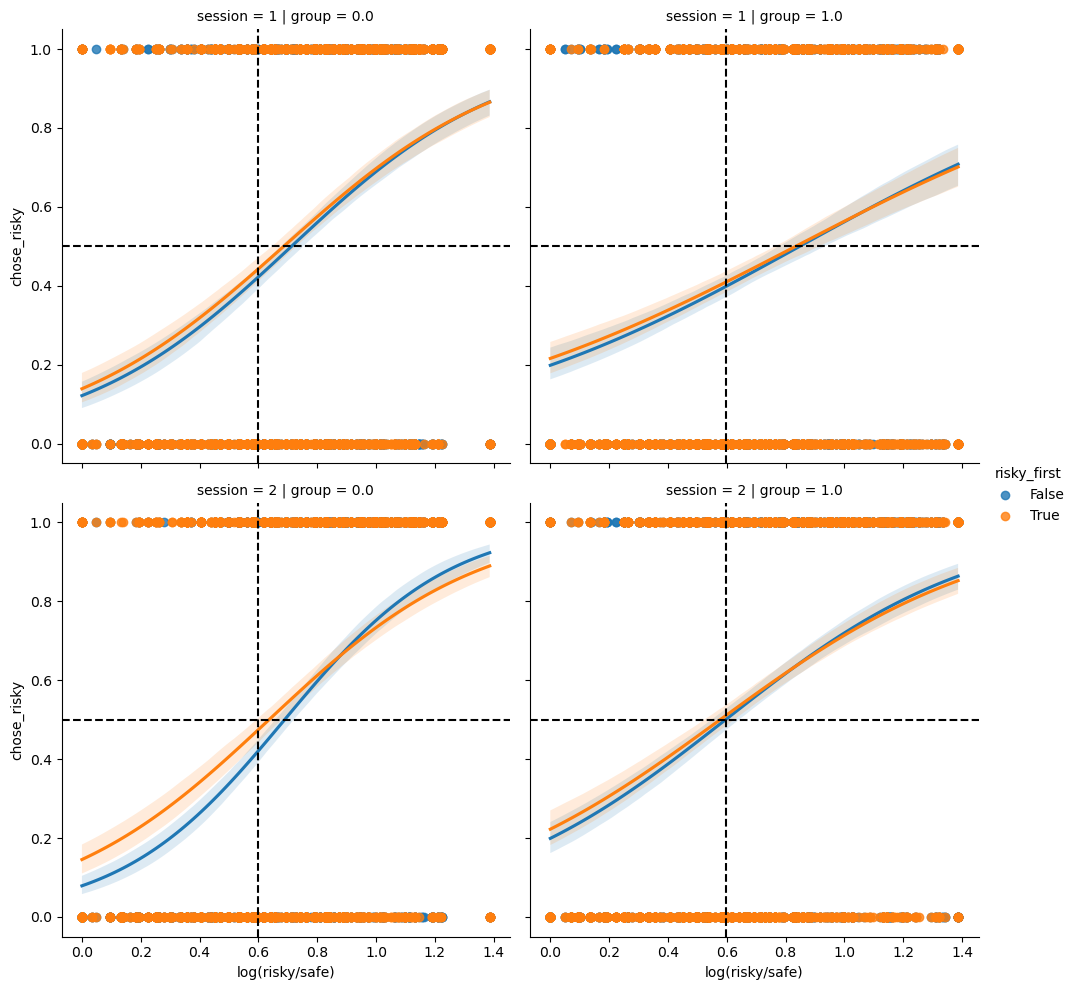

In [5]:
fac = sns.lmplot(x='log(risky/safe)', y='chose_risky', data=df.reset_index(), logistic=True, col='group',row='session', hue='risky_first')

for ax in fac.axes.ravel():
    ax.axhline(.5, c='k', ls='--')
    ax.axvline(np.log(1/.55), c='k', ls='--')

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_51591/3842034007.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 67)` for the same effect.

  sns.catplot(x='n_safe', y='chose_risky', hue='risky_first',


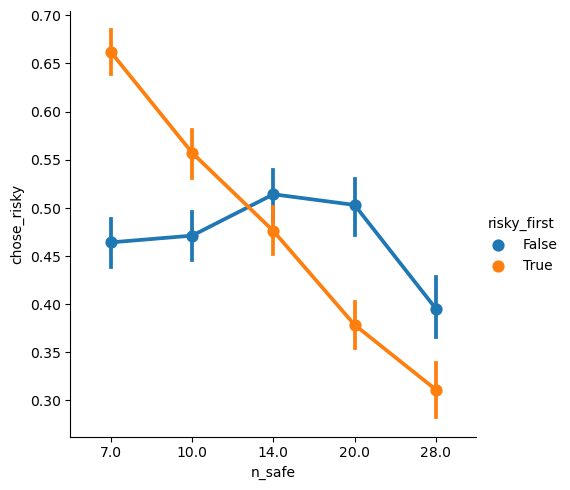

In [ ]:
sns.catplot(x='n_safe', y='chose_risky', hue='risky_first',
data=df.groupby(['subject', 'n_safe', 'risky_first']).mean().reset_index(), kind='point', ci=67)

In [6]:
import bambi
df['x'] = df['log(risky/safe)']

In [7]:
formulae = 'chose_risky ~ x*session*group + (x*session|subject)'
model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())


In [8]:
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)

Modeling the probability that chose_risky==1
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, x, session, x:session, group, x:group, session:group, x:session:group, 1|subject_sigma, 1|subject_offset, x|subject_sigma, x|subject_offset, session|subject_sigma, session|subject_offset, x:session|subject_sigma, x:session|subject_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1321 seconds.


In [9]:
# save model fit
import arviz as az
import os.path as op

bids_folder = '/Users/mrenke/data/ds-stressrisk'

target_folder = op.join(bids_folder, 'derivatives', 'cogmodels')

az.to_netcdf(traces, op.join(target_folder, f'bambi-RNP-fit_trace.netcdf'))

'/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/bambi-RNP-fit_trace.netcdf'

In [10]:
# no session
import scipy.stats as ss

def invprobit(x):
    return ss.norm.ppf(x)

def extract_rnp_precision(trace, model, data, group=False):

    data = data.reset_index()

    if group:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique()[[0]],
                                                [0, 1],
                                                data['n_safe'].unique(),
                                                [False, True]],
                                                names=['subject', 'x', 'n_safe', 'risky_first']
                                                ).to_frame().reset_index(drop=True)
    else:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique(),
                                                [0, 1],
                                                data['n_safe'].unique(),
                                                [False, True]],
                                                names=['subject', 'x', 'n_safe', 'risky_first']
                                                ).to_frame().reset_index(drop=True)

    pred = model.predict(trace, 'mean', fake_data, inplace=False)['posterior']['chose_risky_mean']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'x')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

    return intercept, gamma

In [14]:
# with sesssion as factor
import scipy.stats as ss
def invprobit(x):
    return ss.norm.ppf(x)

def extract_rnp_precision(trace, model, data, group=False):

    data = data.reset_index()

    if group:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique()[[0]],
                                                [0, 1],
                                                data['session'].unique(),
                                                data['group'].unique()],
                                                names=['subject', 'x', 'session', 'group']
                                                ).to_frame().reset_index(drop=True)
    else:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique(),
                                                [0, 1],
                                                data['session'].unique(),
                                                data['group'].unique()],
                                                names=['subject', 'x', 'session', 'group']
                                                ).to_frame().reset_index(drop=True)

    #pred = model.predict(trace, 'mean', fake_data, inplace=False)['posterior']['chose_risky_mean']
    pred = model.predict(trace, 'mean', fake_data, inplace=False, include_group_specific=not group)['posterior']['chose_risky_mean']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'x')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

    return intercept, gamma

In [15]:
import arviz as az

In [ ]:
az.plot_trace(traces)

In [16]:
intercept, gamma = extract_rnp_precision(traces, model, df, False)

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


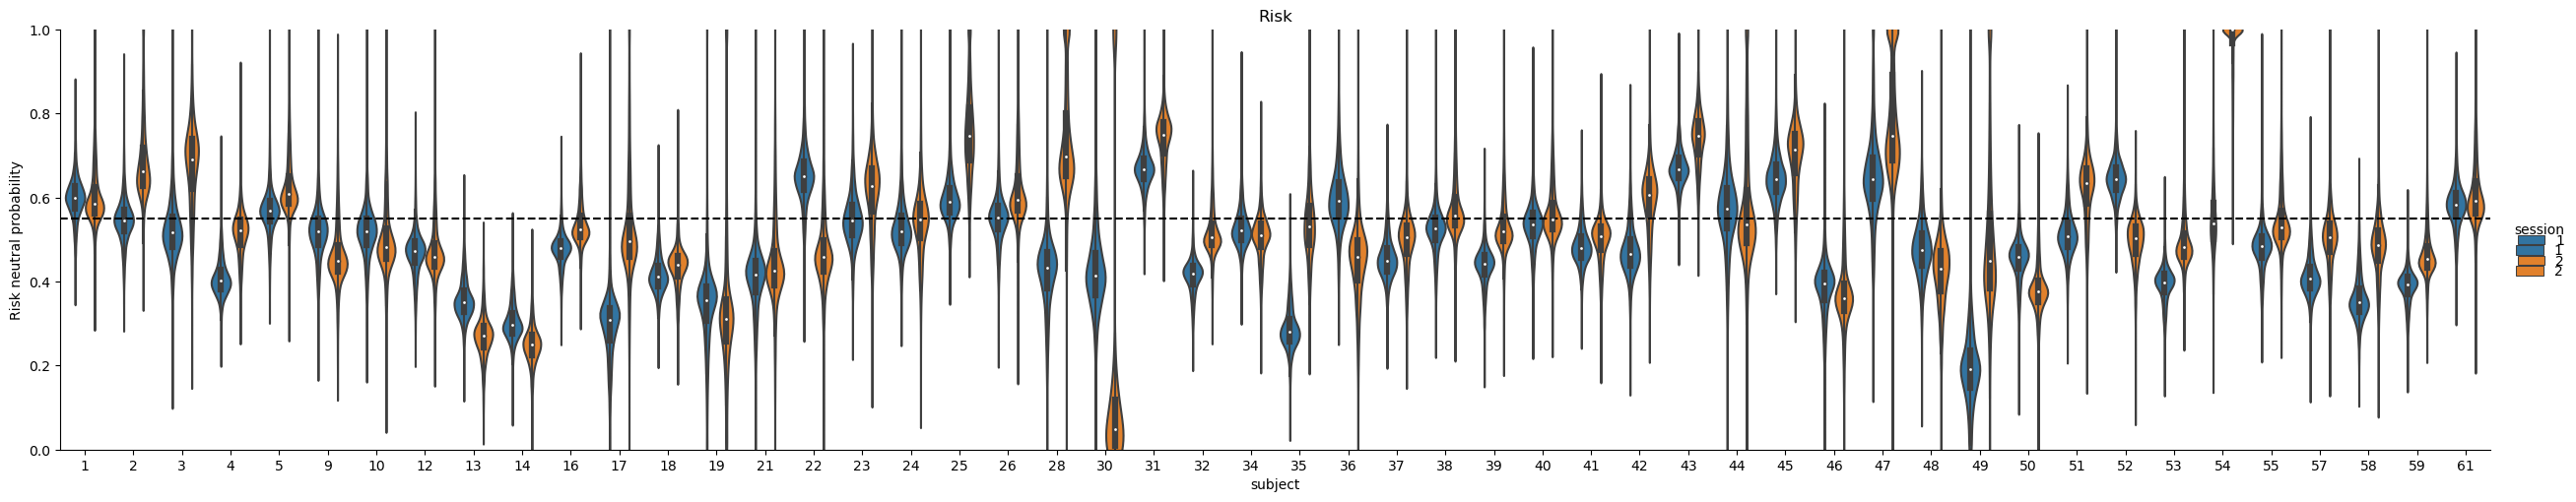

In [19]:
import numpy as np

rnp = np.clip(np.exp(intercept/gamma), 0, 1)

rnp = rnp.stack([1,2])
rnp.columns = ['rnp']

fac = sns.catplot(x='subject', y='rnp', data=rnp.reset_index(), aspect=5., hue='session', kind='violin')
plt.ylim(0, 1)
plt.axhline(.55, c='k', ls='--', label='risk-neutral')
fac.set(title='Risk', ylabel='Risk neutral probability')
fac.add_legend()

In [22]:
from stress_risk.behavior.utils import add_cond2df

rnp = add_cond2df(rnp)



In [26]:
rnp.groupby(['subject','session']).mean()

rnp  group
subject session                 
1       1        0.600260    0.0
        2        0.600111    0.0
2       1        0.545680    0.0
        2        0.684008    0.0
3       1        0.521614    1.0
...                   ...    ...
58      2        0.483389    1.0
59      1        0.387507    0.0
        2        0.464295    0.0
61      1        0.583817    0.0
        2        0.611670    0.0

[100 rows x 2 columns]

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_51591/48917856.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rnp.groupby('subject').mean(), bins=25)


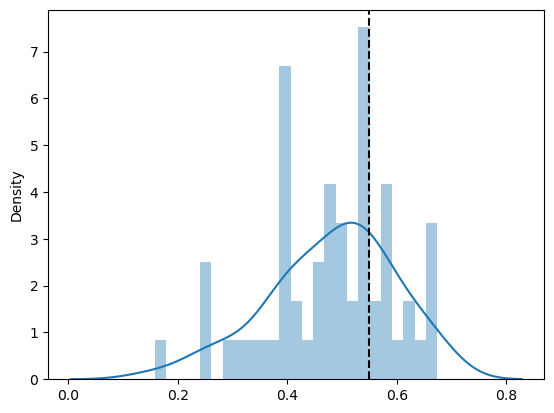

In [ ]:
sns.distplot(rnp.groupby('subject').mean(), bins=25)
plt.axvline(.55, c='k', ls='--')

In [27]:
#rnp.groupby('subject').mean().to_csv('subjectwise_rnp.tsv', sep='\t')
rnp.groupby(['subject','session']).mean().to_csv('subject-session-wise_rnp.tsv', sep='\t')

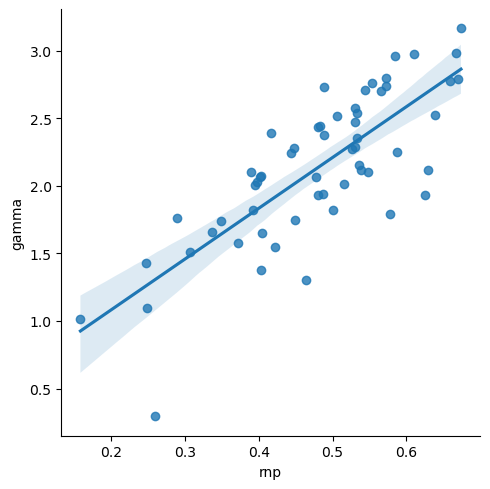

In [ ]:
gamma_ = gamma.stack([1, 2]).groupby(['subject']).mean()
gamma_.columns = ['gamma']

rnp_ = rnp.groupby(['subject']).mean()

pars = rnp_.join(gamma_)
sns.lmplot(x='rnp', y='gamma', data=pars)

In [ ]:
gamma_.to_csv('subjectwise_gamma.tsv', sep='\t')

In [ ]:
pwd

'/Users/mrenke/git/stress_risk/stress_risk/subject_selection'